In [151]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import(
    
    train_test_split,
    GridSearchCV,
    RandomizedSearchCV
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [152]:
df=pd.read_csv("dataset.csv")
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,30669,Male,3.0,0,0,No,children,Rural,95.12,18.0,NaN,0
1,30468,Male,58.0,1,0,Yes,Private,Urban,87.96,39.2,never smoked,0
2,16523,Female,8.0,0,0,No,Private,Urban,110.89,17.6,NaN,0
3,56543,Female,70.0,0,0,Yes,Private,Rural,69.04,35.9,formerly smoked,0
4,46136,Male,14.0,0,0,No,Never_worked,Rural,161.28,19.1,NaN,0


In [153]:
df.tail()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
43395,56196,Female,10.0,0,0,No,children,Urban,58.64,20.4,never smoked,0
43396,5450,Female,56.0,0,0,Yes,Govt_job,Urban,213.61,55.4,formerly smoked,0
43397,28375,Female,82.0,1,0,Yes,Private,Urban,91.94,28.9,formerly smoked,0
43398,27973,Male,40.0,0,0,Yes,Private,Urban,99.16,33.2,never smoked,0
43399,36271,Female,82.0,0,0,Yes,Private,Urban,79.48,20.6,never smoked,0


In [154]:
df.sample(5)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
36316,32739,Male,24.0,0,0,No,Private,Urban,61.34,24.8,NaN,0
33247,49780,Male,69.0,0,1,Yes,Self-employed,Rural,60.81,41.9,NaN,0
15777,18195,Female,0.4,0,0,No,children,Rural,92.68,15.4,NaN,0
40270,59100,Male,2.0,0,0,No,children,Rural,80.42,22.6,NaN,0
39995,2728,Female,3.0,0,0,No,children,Rural,81.27,22.6,NaN,0


In [155]:
for cols in df.columns:
    print(f"\ncolun: {cols}")
    print(df[cols].unique())


colun: id
[30669 30468 16523 ... 28375 27973 36271]

colun: gender
<StringArray>
['Male', 'Female', 'Other']
Length: 3, dtype: str

colun: age
[3.00e+00 5.80e+01 8.00e+00 7.00e+01 1.40e+01 4.70e+01 5.20e+01 7.50e+01
 3.20e+01 7.40e+01 7.90e+01 3.70e+01 4.00e+01 3.50e+01 2.00e+01 4.20e+01
 4.40e+01 6.50e+01 5.70e+01 4.90e+01 7.10e+01 5.90e+01 2.50e+01 6.70e+01
 3.80e+01 5.40e+01 2.70e+01 2.30e+01 5.50e+01 1.70e+01 1.30e+01 4.00e+00
 1.60e+01 2.20e+01 4.50e+01 6.60e+01 6.90e+01 5.30e+01 7.80e+01 4.30e+01
 5.10e+01 3.00e+01 4.60e+01 6.10e+01 4.80e+01 2.90e+01 1.10e+01 7.60e+01
 2.10e+01 1.80e+01 3.30e+01 8.20e+01 2.40e+01 3.40e+01 6.40e+01 6.80e+01
 6.00e+01 3.60e+01 3.90e+01 6.40e-01 7.20e+01 4.10e+01 5.60e+01 8.80e-01
 5.00e+00 8.00e+01 2.60e+01 3.10e+01 7.00e+00 1.20e+01 6.30e+01 6.20e+01
 2.00e+00 8.10e+01 9.00e+00 1.50e+01 2.80e+01 1.00e+01 7.70e+01 1.80e+00
 3.20e-01 1.08e+00 7.30e+01 5.00e+01 1.90e+01 6.00e+00 1.16e+00 1.00e+00
 1.40e+00 1.72e+00 2.40e-01 1.64e+00 1.56e+00 7.20e-0

In [156]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 43400 entries, 0 to 43399
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 43400 non-null  int64  
 1   gender             43400 non-null  str    
 2   age                43400 non-null  float64
 3   hypertension       43400 non-null  int64  
 4   heart_disease      43400 non-null  int64  
 5   ever_married       43400 non-null  str    
 6   work_type          43400 non-null  str    
 7   Residence_type     43400 non-null  str    
 8   avg_glucose_level  43400 non-null  float64
 9   bmi                41938 non-null  float64
 10  smoking_status     30108 non-null  str    
 11  stroke             43400 non-null  int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 4.0 MB


In [157]:
df.shape

(43400, 12)

In [158]:
df.duplicated().sum()

np.int64(0)

In [159]:
df.columns

Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='str')

In [160]:
df.drop("id",axis=1,inplace=True)

In [161]:
df.describe()

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,43400.000000,43400.000000,43400.000000,43400.000000,41938.000000,43400.000000
mean,42.217894,0.093571,0.047512,104.482750,28.605038,0.018041
std,22.519649,0.291235,0.212733,43.111751,7.770020,0.133103
min,0.080000,0.000000,0.000000,55.000000,10.100000,0.000000
25%,24.000000,0.000000,0.000000,77.540000,23.200000,0.000000
50%,44.000000,0.000000,0.000000,91.580000,27.700000,0.000000
75%,60.000000,0.000000,0.000000,112.070000,32.900000,0.000000
max,82.000000,1.000000,1.000000,291.050000,97.600000,1.000000


In [162]:
df.isnull().sum()

gender                   0
age                      0
hypertension             0
heart_disease            0
ever_married             0
work_type                0
Residence_type           0
avg_glucose_level        0
bmi                   1462
smoking_status       13292
stroke                   0
dtype: int64

In [163]:
numerical_col=df.select_dtypes(include="number").columns
catigorical_cols=df.select_dtypes(include=["object","string","category"]).columns

for cols in numerical_col:
    df[cols]=df[cols].fillna(df[cols].median())

for cols in catigorical_cols:
    df[cols]=df[cols].fillna(df[cols].mode()[0])

In [164]:
df.isnull().sum()

gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

In [165]:
df.dtypes

gender                   str
age                  float64
hypertension           int64
heart_disease          int64
ever_married             str
work_type                str
Residence_type           str
avg_glucose_level    float64
bmi                  float64
smoking_status           str
stroke                 int64
dtype: object

In [166]:
df["stroke"].unique()

array([0, 1])

{'whiskers': [<matplotlib.lines.Line2D at 0x2591bd542d0>,
 'caps': [<matplotlib.lines.Line2D at 0x2591bd54550>,
 'boxes': [<matplotlib.lines.Line2D at 0x2591bd54190>],
 'medians': [<matplotlib.lines.Line2D at 0x2591bd547d0>],
 'fliers': [<matplotlib.lines.Line2D at 0x2591bd54910>],
 'means': []}

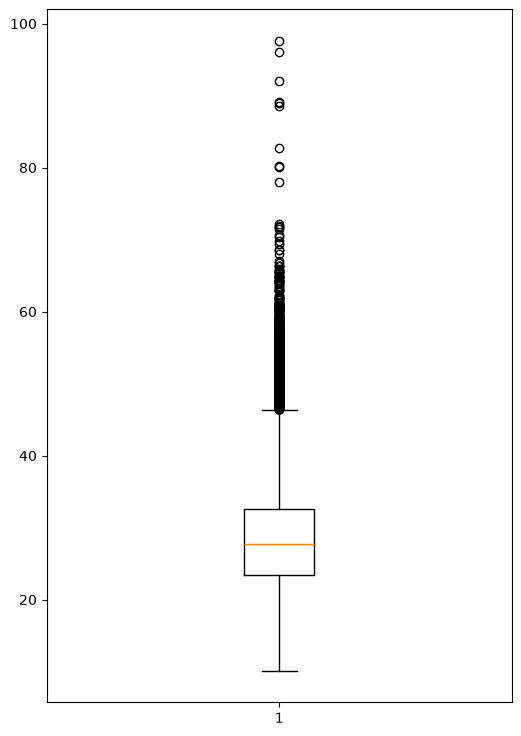

In [167]:
plt.figure(figsize=(6,9))

plt.boxplot(df["bmi"])


# encoded

In [168]:
cat_cols=df.select_dtypes(include="object").columns

C:\Users\Administrator\AppData\Local\Temp\ipykernel_20288\1520381097.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols=df.select_dtypes(include="object").columns


In [169]:
df.head()# find unipe values for each columns
for col in cat_cols:
    print(col)
    print(df[col].unique())
    print("_"*40)

gender
<StringArray>
['Male', 'Female', 'Other']
Length: 3, dtype: str
________________________________________
ever_married
<StringArray>
['No', 'Yes']
Length: 2, dtype: str
________________________________________
work_type
<StringArray>
['children', 'Private', 'Never_worked', 'Self-employed', 'Govt_job']
Length: 5, dtype: str
________________________________________
Residence_type
<StringArray>
['Rural', 'Urban']
Length: 2, dtype: str
________________________________________
smoking_status
<StringArray>
['never smoked', 'formerly smoked', 'smokes']
Length: 3, dtype: str
________________________________________


In [170]:
df["work_type"]=df["work_type"].replace({
    'children':0,
    'Private':1,
    'Never_worked':2,
    'Self-employed':3,
    'Govt_job':4
})

In [171]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 43400 entries, 0 to 43399
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             43400 non-null  str    
 1   age                43400 non-null  float64
 2   hypertension       43400 non-null  int64  
 3   heart_disease      43400 non-null  int64  
 4   ever_married       43400 non-null  str    
 5   work_type          43400 non-null  object 
 6   Residence_type     43400 non-null  str    
 7   avg_glucose_level  43400 non-null  float64
 8   bmi                43400 non-null  float64
 9   smoking_status     43400 non-null  str    
 10  stroke             43400 non-null  int64  
dtypes: float64(3), int64(3), object(1), str(4)
memory usage: 3.6+ MB


In [172]:
df["gender"]=df["gender"].replace({
    "Female":0,
    "Male":1,
    "Other":2
})

In [173]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["ever_married"] = le.fit_transform(df["ever_married"])

In [174]:
df=df.replace({
    "Female":0,
    "Male":1,
    "Others":2
})

df=df.replace({
    "Urban":0,
    "Rural":1
})

df=df.replace({
    'never smoked':0,
    'smokes':1,
    'formerly smoked':2
})

# Feature selection

In [175]:
x=df.drop("stroke",axis=1)
y=df["stroke"]

## Train the model

In [176]:
x_train,x_test,y_train,y_test=train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [177]:
import numpy as np

print(np.unique(y_train, return_counts=True))

(array([0, 1]), array([34094,   626]))


In [178]:

import numpy as np

print(np.unique(y_train, return_counts=True))

(array([0, 1]), array([34094,   626]))


# logisticregression

In [179]:
model=LogisticRegression(
    class_weight="balanced",
    max_iter=1000
    )
model.fit(x_train,y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Defaul

In [180]:
y_pred=model.predict(x_test)
np.unique(y_pred)

array([0, 1])

In [181]:
print("accuracy_score:",accuracy_score(y_test,y_pred))
print("precision_score:",precision_score(y_test,y_pred))
print("recall_score:",recall_score(y_test,y_pred))
print("f1_score:",f1_score(y_test,y_pred))
print("confusion_matrix:\n",confusion_matrix(y_test,y_pred))

accuracy_score: 0.7435483870967742
precision_score: 0.05390254420008624
recall_score: 0.7961783439490446
f1_score: 0.10096930533117932
confusion_matrix:
 [[6329 2194]
 [  32  125]]


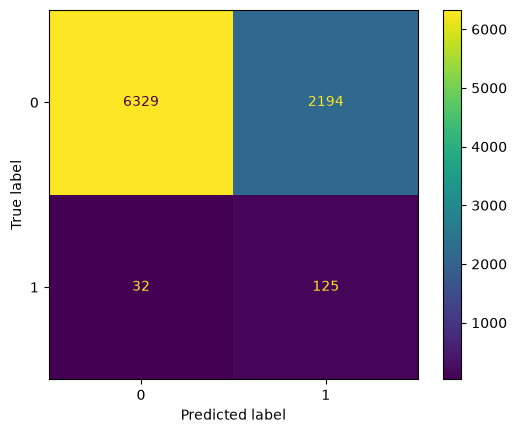

In [182]:
cm=(y_test,y_pred)

ConfusionMatrixDisplay.from_predictions(y_test,y_pred)

plt.savefig("logisticregression_confusionmatrix.png")

# DecisionTree

In [183]:
model=DecisionTreeClassifier(
    class_weight="balanced",
    random_state=42
)


In [184]:
model.fit(x_train,y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: dict, list of dict or ""balanced"", default=NoneWeights associated with classes in the form ``{class_label: weight}``.If None, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are 

In [185]:
y_pred_tree = model.predict(x_test)

In [186]:
print("accuracy_score:",accuracy_score(y_test,y_pred_tree))
print("precision_score:",precision_score(y_test,y_pred_tree))
print("recall_score:",recall_score(y_test,y_pred_tree))
print("f1_score:",f1_score(y_test,y_pred_tree))
print("confusion_matrix:\n",confusion_matrix(y_test,y_pred_tree))

accuracy_score: 0.9670506912442396
precision_score: 0.06711409395973154
recall_score: 0.06369426751592357
f1_score: 0.06535947712418301
confusion_matrix:
 [[8384  139]
 [ 147   10]]


# GrideSearchCV

In [187]:
param = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 5, 8, 10],
    "min_samples_split": [2, 10],
    "min_samples_leaf": [1, 5],
    "class_weight": [None, "balanced"]
}

In [188]:
grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid.fit(x_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'class_weight': [None, 'balanced'], 'criterion': ['gini', 'entropy'], 'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 5], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"

In [189]:
# best parameter

print(grid.best_params_)
# best model

best_model = grid.best_estimator_

{'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [190]:
# best score
print(grid.best_score_)

0.10507979004160233


In [191]:
y_pred_grid = best_model.predict(x_test)

In [192]:
print("Accuracy:", accuracy_score(y_test, y_pred_grid))
print("Precision:", precision_score(y_test, y_pred_grid))
print("Recall:", recall_score(y_test, y_pred_grid))
print("F1:", f1_score(y_test, y_pred_grid))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_grid))

Accuracy: 0.6634792626728111
Precision: 0.042686962276637985
Recall: 0.821656050955414
F1: 0.08115759672853098
Confusion Matrix:
 [[5630 2893]
 [  28  129]]


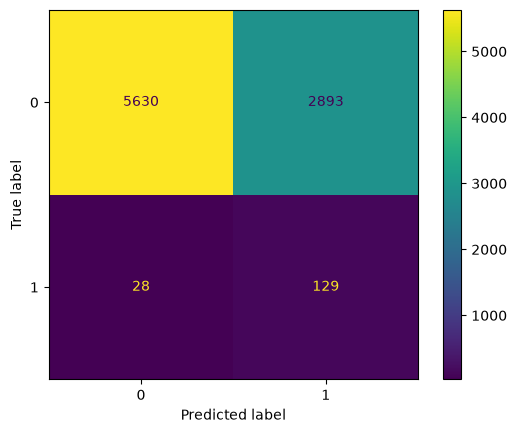

In [193]:
conusion_M=(y_test,y_pred_grid)

ConfusionMatrixDisplay.from_predictions(y_test,y_pred_grid)

plt.savefig("Conusion Matrix gridsearchcv plot.png")

# RandomizedSearchCV

In [194]:
rand_para={
    "criterion":["gini","entropy"],
    "max_depth":[1,2,3,4,5,6,7,8,9,10],
    "min_samples_split":[2,5,10],
    "class_weight": [None, "balanced"]
}

In [195]:
rand=RandomizedSearchCV(
    DecisionTreeClassifier(random_state=42),
    rand_para,
    n_iter=30,
    cv=5,
    scoring="f1",
    random_state=42
)

In [196]:
rand.fit(x_train,y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'class_weight': [None, 'balanced'], 'criterion': ['gini', 'entropy'], 'max_depth': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for mu

In [197]:
# best parameter
print("best parameter:",rand.best_params_)
# best model
print("best model:",rand.best_estimator_)
# best score
print("best score",rand.best_score_)

best parameter: {'min_samples_split': 2, 'max_depth': 9, 'criterion': 'entropy', 'class_weight': 'balanced'}
best model: DecisionTreeClassifier(class_weight='balanced', criterion='entropy',
                       max_depth=9, random_state=42)
best score 0.10238208090159681


In [198]:
best_model = rand.best_estimator_

y_pred_rand = best_model.predict(x_test)

In [199]:
print("Accuracy:", accuracy_score(y_test, y_pred_rand))
print("Precision:", precision_score(y_test, y_pred_rand))
print("Recall:", recall_score(y_test, y_pred_rand))
print("F1:", f1_score(y_test, y_pred_rand))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rand))

Accuracy: 0.7895161290322581
Precision: 0.04816017316017316
Recall: 0.5668789808917197
F1: 0.08877805486284289
Confusion Matrix:
 [[6764 1759]
 [  68   89]]


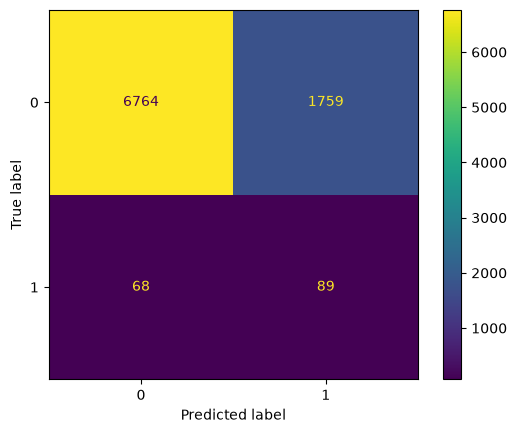

In [200]:
cm_rand=(y_test, y_pred_rand)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rand)

plt.savefig("Conusion Matrix Randsearchcv plot.png")

# Save model


In [201]:
import joblib
from sklearn.linear_model import LogisticRegression

# Create the final model
final_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000
)

# Train the final model
final_model.fit(x_train, y_train)

# Save the trained model
joblib.dump(final_model, "stroke_prediction_model.pkl")

print("Final model saved successfully!")

Final model saved successfully!


# Load the saved model

In [202]:
# Load the saved model
loaded_model = joblib.load("stroke_prediction_model.pkl")

# Test it
test_prediction = loaded_model.predict(x_test)

print("Saved model loaded successfully!")
print("Test predictions:", test_prediction[:10])

Saved model loaded successfully!
Test predictions: [0 0 1 0 1 0 0 0 0 0]


# check where my model saved

In [204]:
import os

print(os.getcwd())

d:\01_Github repo folders\Ezitech internship projects\Stroke Prediction Dataset


# check that file exist

In [205]:
import os

print(os.path.exists("stroke_prediction_model.pkl"))

True
